--- Training Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        230130 non-null  int64         
 1   date      230130 non-null  datetime64[ns]
 2   country   230130 non-null  object        
 3   store     230130 non-null  object        
 4   product   230130 non-null  object        
 5   num_sold  221259 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 10.5+ MB
None

--- Missing Values in Training Data ---
id             0
date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

--- Unique Categories ---
Countries: ['Canada' 'Finland' 'Italy' 'Kenya' 'Norway' 'Singapore']
Stores: ['Discount Stickers' 'Stickers for Less' 'Premium Sticker Mart']
Products: ['Holographic Goose' 'Kaggle' 'Kaggle Tiers' 'Kerneler'
 'Ker

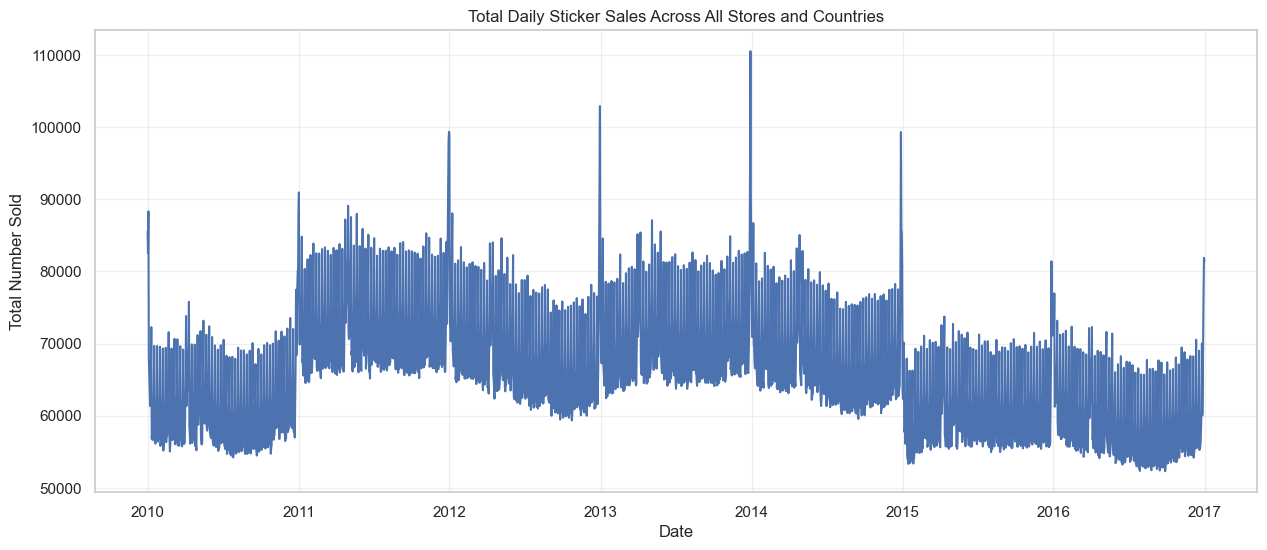

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

def load_and_inspect_data(train_path='train.csv', test_path='test.csv'):
    # Load datasets
    try:
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
    except FileNotFoundError:
        print("Error: Dataset files not found. Please ensure train.csv and test.csv are in the correct directory.")
        return None, None

    # Convert date columns to datetime objects
    train_df['date'] = pd.to_datetime(train_df['date'])
    test_df['date'] = pd.to_datetime(test_df['date'])

    print("--- Training Data Overview ---")
    print(train_df.info())
    print("\n--- Missing Values in Training Data ---")
    print(train_df.isnull().sum())
    
    print("\n--- Unique Categories ---")
    print(f"Countries: {train_df['country'].unique()}")
    print(f"Stores: {train_df['store'].unique()}")
    print(f"Products: {train_df['product'].unique()}")
    
    print("\n--- Summary Statistics ---")
    print(train_df.describe(include='all'))

    return train_df, test_df

# Execute the data loading function
train_data, test_data = load_and_inspect_data()

# Basic Temporal Visualization
if train_data is not None:
    plt.figure(figsize=(15, 6))
    daily_sales = train_data.groupby('date')['num_sold'].sum().reset_index()
    sns.lineplot(data=daily_sales, x='date', y='num_sold')
    plt.title('Total Daily Sticker Sales Across All Stores and Countries')
    plt.xlabel('Date')
    plt.ylabel('Total Number Sold')
    plt.grid(True, alpha=0.3)
    plt.show()